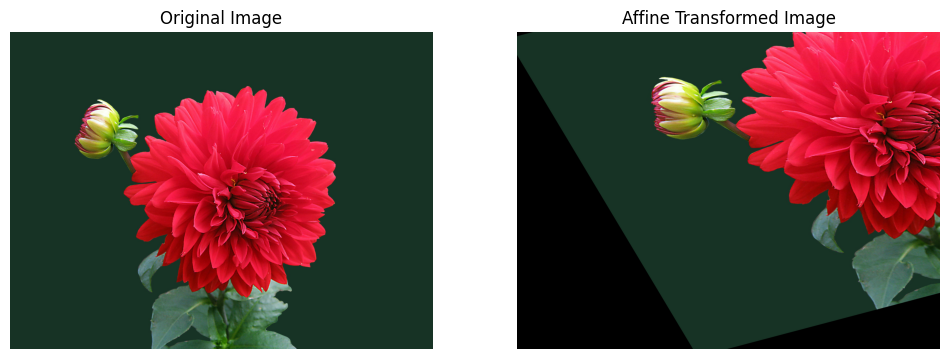

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Load the image ---
# The user has confirmed 'image.jpg' is uploaded.
img = cv2.imread('image.jpg') # Ensure 'image.jpg' is in your Colab environment

if img is None:
    raise ValueError("Failed to load image. Please ensure 'image.jpg' exists and is a valid image file.")

# It's good practice to convert BGR to RGB for displaying with matplotlib
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

rows, cols, ch = img.shape

# --- 2. Define source and destination points ---
# We need 3 corresponding points to define an affine transformation.
# These points are typically vertices of a triangle.

# Source points (from the original image)
# Example: top-left, top-right, bottom-left corners
pts1 = np.float32([
    [50, 50],   # Top-left
    [200, 50],  # Top-right
    [50, 200]   # Bottom-left
])

# Destination points (where the source points should go in the new image)
# These define the scaling, rotation, shear, and translation.
# Example: shifted, rotated, scaled positions
pts2 = np.float32([
    [10, 100],  # New position for top-left
    [200, 50],  # New position for top-right (example: might be rotated)
    [100, 250]  # New position for bottom-left (example: might be sheared)
])

# --- 3. Calculate the affine transformation matrix ---
M = cv2.getAffineTransform(pts1, pts2)

# --- 4. Apply the affine transformation ---
# The third argument is the size of the output image (width, height)
dst = cv2.warpAffine(img, M, (cols, rows))

# Convert transformed image to RGB for display
dst_rgb = cv2.cvtColor(dst, cv2.COLOR_BGR2RGB)

# --- 5. Display the original and transformed images ---
plt.figure(figsize=(12, 6))

plt.subplot(121)
plt.imshow(img_rgb)
plt.title('Original Image')
plt.axis('off')

plt.subplot(122)
plt.imshow(dst_rgb)
plt.title('Affine Transformed Image')
plt.axis('off')

plt.show()